<a href="https://colab.research.google.com/github/Roshni-AngelAlex/MACHINE-LEARNING-LAB-24ADI003-/blob/main/MLLABEX9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MACHINE LEARNING LAB EXPERIMENT 9**

**Recommendation Systems using Collaborative Filtering Techniques**

**NAME:ROSHNI ANGEL A / ROLLNO:24BAD101**

**SCENARIO 1** USER-BASED COLLABORATIVE FILTERING

**Problem Statement**

Recommend movies to users based on similar users' preferences.


**Dataset (Kaggle – Public)**

MovieLens Dataset

Dataset Link: https://www.kaggle.com/datasets/vahidehdashti/movielens


Recommended Movies:
movieId
318    21.996880
474    21.006675
655    19.883163
423    19.857810
403    19.788317
dtype: float64
RMSE: 84.03197039868728
Precision@5: 0.0


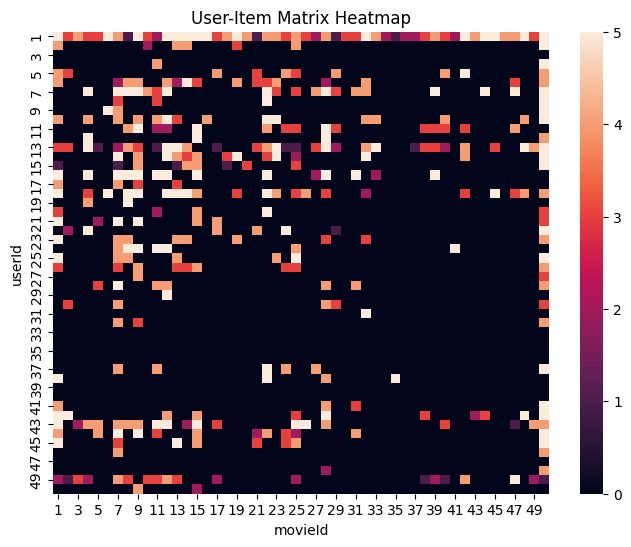

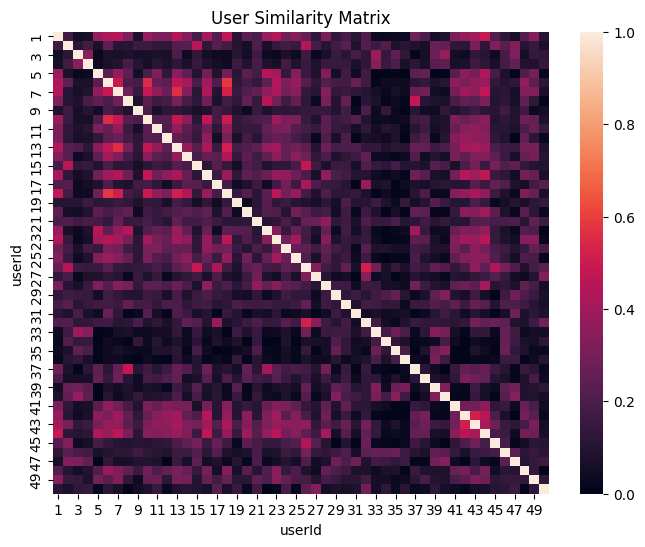

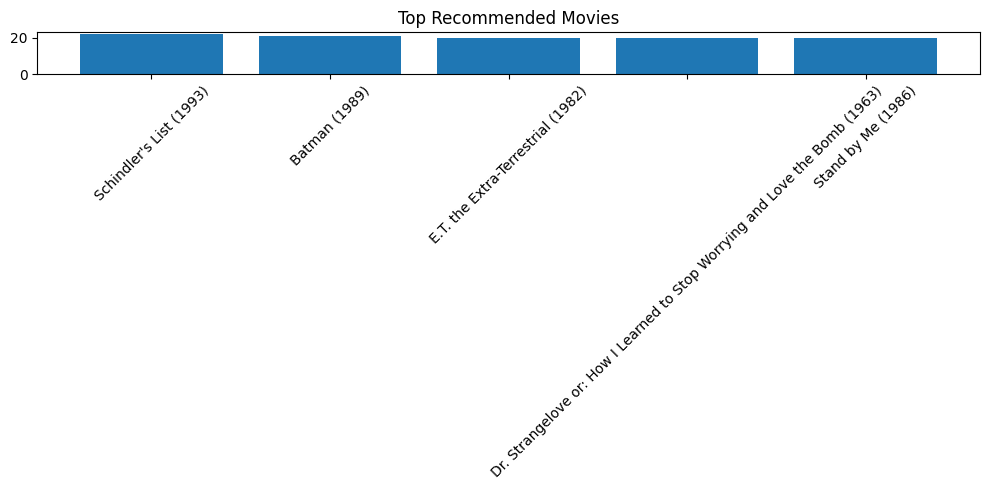

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from math import sqrt

# Load dataset
ratings = pd.read_csv(
    "u.data",
    sep="\t",
    names=["userId","movieId","rating","timestamp"]
)

movies = pd.read_csv(
    "u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0,1],
    names=["movieId","title"]
)

# User-Item Matrix
user_item_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
).fillna(0)

# User similarity
user_similarity = cosine_similarity(user_item_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

# Similar users
def get_similar_users(user_id, top_n=5):
    return user_similarity_df[user_id]\
        .sort_values(ascending=False)[1:top_n+1]

# Recommendation function
def recommend_movies(user_id, top_n=5):

    similar_users = get_similar_users(user_id,10)

    weighted_ratings = np.dot(
        similar_users.values,
        user_item_matrix.loc[similar_users.index]
    )

    scores = pd.Series(
        weighted_ratings,
        index=user_item_matrix.columns
    )

    watched = user_item_matrix.loc[user_id]
    scores = scores[watched == 0]

    return scores.sort_values(ascending=False).head(top_n)

user_id = 1
recommended_movies = recommend_movies(user_id)

print("Recommended Movies:")
print(recommended_movies)

# Evaluation
predicted_ratings = np.dot(user_similarity, user_item_matrix)

rmse = sqrt(mean_squared_error(
    user_item_matrix.values.flatten(),
    predicted_ratings.flatten()
))

print("RMSE:", rmse)

def precision_at_k(recommended, relevant, k=5):
    recommended = set(recommended[:k])
    relevant = set(relevant)
    return len(recommended & relevant) / k

precision = precision_at_k(
    recommended_movies.index.tolist(),
    ratings[ratings.userId==user_id]["movieId"].tolist()
)

print("Precision@5:", precision)

# Heatmap: User-Item Matrix
plt.figure(figsize=(8,6))
sns.heatmap(user_item_matrix.iloc[:50,:50])
plt.title("User-Item Matrix Heatmap")
plt.show()

# Heatmap: Similarity Matrix
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:50,:50])
plt.title("User Similarity Matrix")
plt.show()

# Top Recommended Movies
recommended_titles = movies[
    movies.movieId.isin(recommended_movies.index)
]

plt.figure(figsize=(10,5))
plt.bar(recommended_titles["title"],
        recommended_movies.values)

plt.xticks(rotation=45)
plt.title("Top Recommended Movies")
plt.tight_layout()
plt.show()

**SCENARIO 2** – ITEM-BASED COLLABORATIVE FILTERING

**Problem Statement**

Recommend similar items (movies/products) based on user ratings.

Dataset (Kaggle – Public)

MovieLens Dataset

Dataset Link: https://www.kaggle.com/datasets/vahidehdashti/movielens


Dataset Loaded Successfully ✅
   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596
Matrix Shape: (1682, 943)

Top Similar Movies:
movieId
50     0.734572
181    0.699925
121    0.689786
117    0.664555
405    0.641322
Name: 1, dtype: float64

Recommended Movies:
movieId
423    394.094117
655    368.216701
568    367.805253
403    364.943551
385    363.508132
dtype: float64

RMSE Comparison
User-Based RMSE: 84.03197039868728
Item-Based RMSE: 86.85297234519365
Precision@5: 0.0


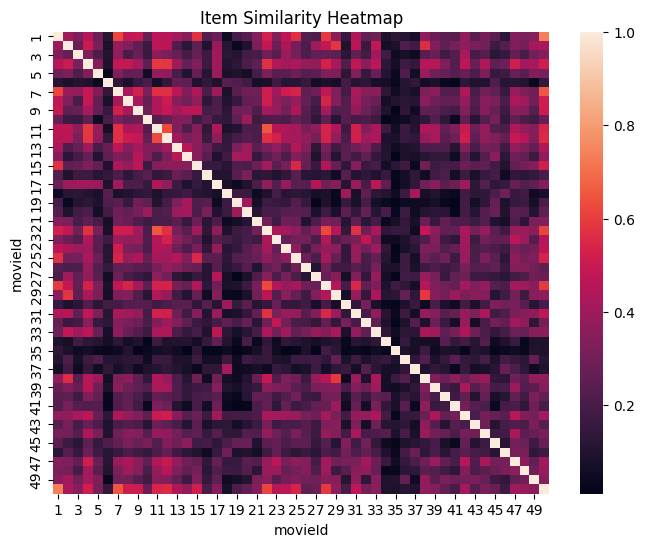

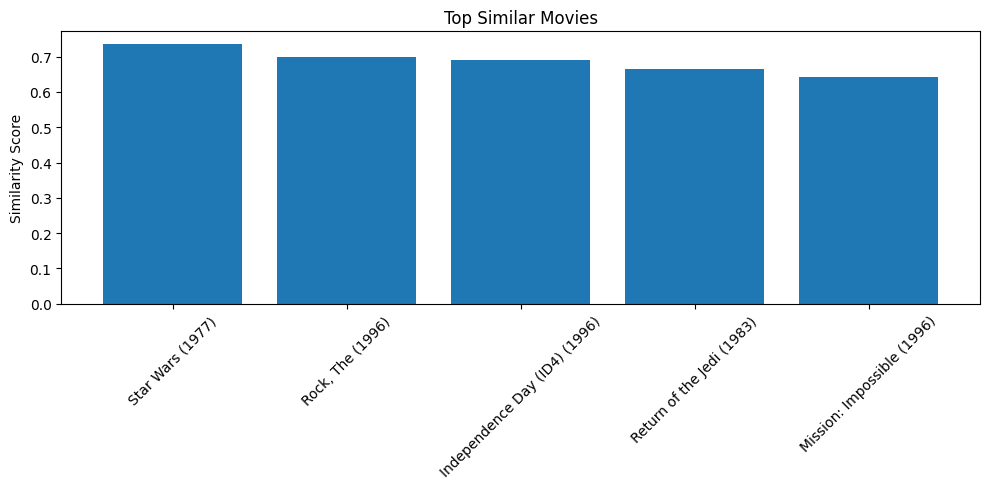

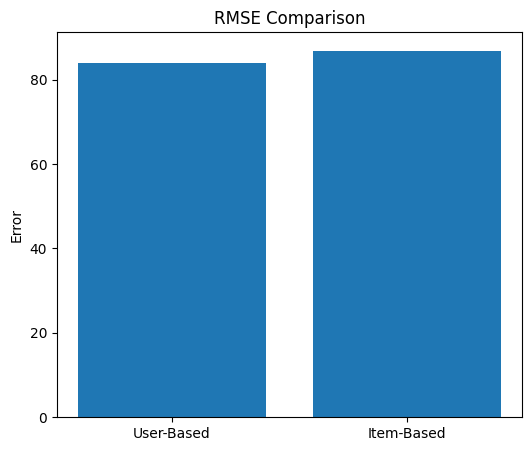


Program Completed Successfully


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from math import sqrt

# 1. LOAD DATASET (COLAB PATH)

ratings = pd.read_csv(
    "u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

movies = pd.read_csv(
    "u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0,1],
    names=["movieId","title"]
)

print("Dataset Loaded Successfully ✅")
print(ratings.head())

# 2. CREATE ITEM-USER MATRIX
item_user_matrix = ratings.pivot_table(
    index="movieId",
    columns="userId",
    values="rating"
).fillna(0)

print("Matrix Shape:", item_user_matrix.shape)

# 3. COMPUTE ITEM SIMILARITY

item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

# 4. TOP SIMILAR ITEMS


def get_similar_items(movie_id, top_n=5):
    similar = item_similarity_df[movie_id]\
        .sort_values(ascending=False)[1:top_n+1]
    return similar

movie_id = 1
similar_items = get_similar_items(movie_id)

print("\nTop Similar Movies:")
print(similar_items)

# 5. RECOMMEND ITEMS BASED ON USER HISTORY

def recommend_items(user_id, top_n=5):

    user_ratings = item_user_matrix[user_id]

    scores = np.dot(item_similarity, user_ratings)

    recommendation_scores = pd.Series(
        scores,
        index=item_user_matrix.index
    )

    watched = user_ratings[user_ratings > 0].index
    recommendation_scores = recommendation_scores.drop(watched)

    return recommendation_scores.sort_values(
        ascending=False
    ).head(top_n)

user_id = 1
recommended_items = recommend_items(user_id)

print("\nRecommended Movies:")
print(recommended_items)

# 6. USER vs ITEM BASED COMPARISON


user_item_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
).fillna(0)

user_similarity = cosine_similarity(user_item_matrix)

user_pred = np.dot(user_similarity, user_item_matrix)
item_pred = np.dot(item_similarity, item_user_matrix)

# 7. EVALUATION

user_rmse = sqrt(mean_squared_error(
    user_item_matrix.values.flatten(),
    user_pred.flatten()
))

item_rmse = sqrt(mean_squared_error(
    item_user_matrix.values.flatten(),
    item_pred.flatten()
))

print("\nRMSE Comparison")
print("User-Based RMSE:", user_rmse)
print("Item-Based RMSE:", item_rmse)


# Precision@K
def precision_at_k(recommended, relevant, k=5):
    recommended = set(recommended[:k])
    relevant = set(relevant)
    return len(recommended & relevant) / k

precision = precision_at_k(
    recommended_items.index.tolist(),
    ratings[ratings.userId==user_id]["movieId"].tolist()
)

print("Precision@5:", precision)

# VISUALIZATION

# 1️⃣ Item Similarity Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:50,:50])
plt.title("Item Similarity Heatmap")
plt.show()


# 2️⃣ Top Similar Items Graph
similar_titles = movies[movies.movieId.isin(similar_items.index)]

plt.figure(figsize=(10,5))
plt.bar(similar_titles["title"], similar_items.values)
plt.xticks(rotation=45)
plt.title("Top Similar Movies")
plt.ylabel("Similarity Score")
plt.tight_layout()
plt.show()


# 3️⃣ Recommendation Comparison Chart
plt.figure(figsize=(6,5))
plt.bar(["User-Based","Item-Based"],
        [user_rmse, item_rmse])
plt.title("RMSE Comparison")
plt.ylabel("Error")
plt.show()

print("\nProgram Completed Successfully")